<a href="https://colab.research.google.com/github/andreybolyubakh-dot/Air-raid-analysis-Bolyubakh/blob/main/Air_raid_prediction_Bolyubakh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initiating Time Series Analysis of Ukrainian Air Raid Alerts...
Attempting to fetch live dataset from GitHub...
Data loaded. Processing and cleaning time series data...


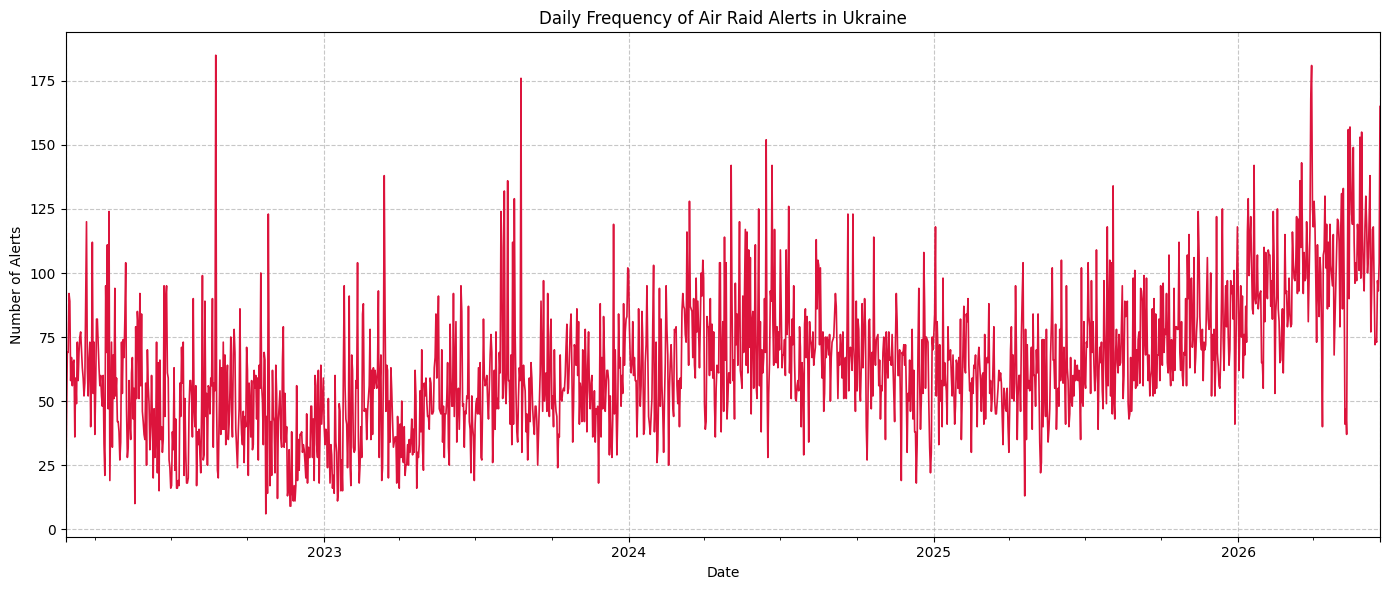

Training ARIMA Time Series Model...

-> Model Evaluation - RMSE: 27.24 alerts/day



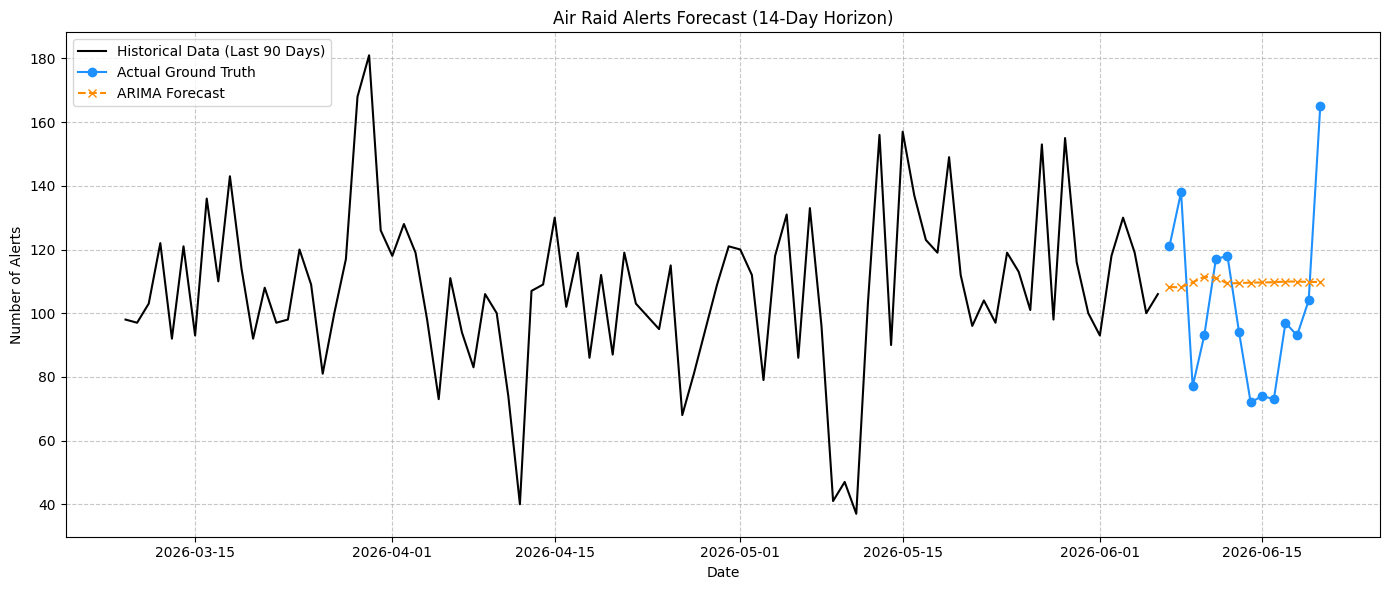

In [1]:
# 1. Install required packages in the cloud environment
!pip install pandas matplotlib statsmodels scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

print("Initiating Time Series Analysis of Ukrainian Air Raid Alerts...")

# 2. Data Acquisition
try:
    print("Attempting to fetch live dataset from GitHub...")
    url = "https://raw.githubusercontent.com/Vadimkin/ukrainian-air-raid-sirens-dataset/main/datasets/volunteer_data_en.csv"
    df = pd.read_csv(url)
    start_col = 'started_at'
except Exception:
    print("Live dataset unavailable. Falling back to synthetic defense dataset...")
    dates = pd.date_range(start="2022-02-24", end=pd.Timestamp.today(), freq="h")
    alerts = np.random.poisson(lam=0.4, size=len(dates))
    df = pd.DataFrame({'started_at': np.repeat(dates, alerts)})
    start_col = 'started_at'

# 3. Data Preprocessing
print("Data loaded. Processing and cleaning time series data...")
df[start_col] = pd.to_datetime(df[start_col], errors='coerce', utc=True)
df = df.dropna(subset=[start_col])
df.set_index(start_col, inplace=True)

daily_alerts = df.resample('D').size()
daily_alerts.name = 'Alert_Count'
daily_alerts = daily_alerts.iloc[:-1]

# 4. Exploratory Data Analysis (EDA) Plot
plt.figure(figsize=(14, 6))
daily_alerts.plot(color='crimson', linewidth=1.2)
plt.title('Daily Frequency of Air Raid Alerts in Ukraine')
plt.xlabel('Date')
plt.ylabel('Number of Alerts')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show() # Displays the graph right in your browser

# 5. Train/Test Split
forecast_horizon = 14
train = daily_alerts.iloc[:-forecast_horizon]
test = daily_alerts.iloc[-forecast_horizon:]

# 6. Modeling
print("Training ARIMA Time Series Model...")
model = ARIMA(train, order=(7, 1, 2))
fitted_model = model.fit()

# 7. Forecasting & Evaluation
predictions = fitted_model.forecast(steps=forecast_horizon)
rmse = mean_squared_error(test, predictions) ** 0.5
print(f"\n-> Model Evaluation - RMSE: {rmse:.2f} alerts/day\n")

# 8. Visualization of Forecast Plot
plt.figure(figsize=(14, 6))
plt.plot(train.index[-90:], train.iloc[-90:], label='Historical Data (Last 90 Days)', color='black')
plt.plot(test.index, test, label='Actual Ground Truth', color='dodgerblue', marker='o')
plt.plot(test.index, predictions, label='ARIMA Forecast', color='darkorange', linestyle='--', marker='x')
plt.title('Air Raid Alerts Forecast (14-Day Horizon)')
plt.xlabel('Date')
plt.ylabel('Number of Alerts')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show() # Displays the second graph right in your browser

Running Upgraded Seasonal Model Analysis...

-> Upgraded SARIMAX RMSE: 27.94 alerts/day


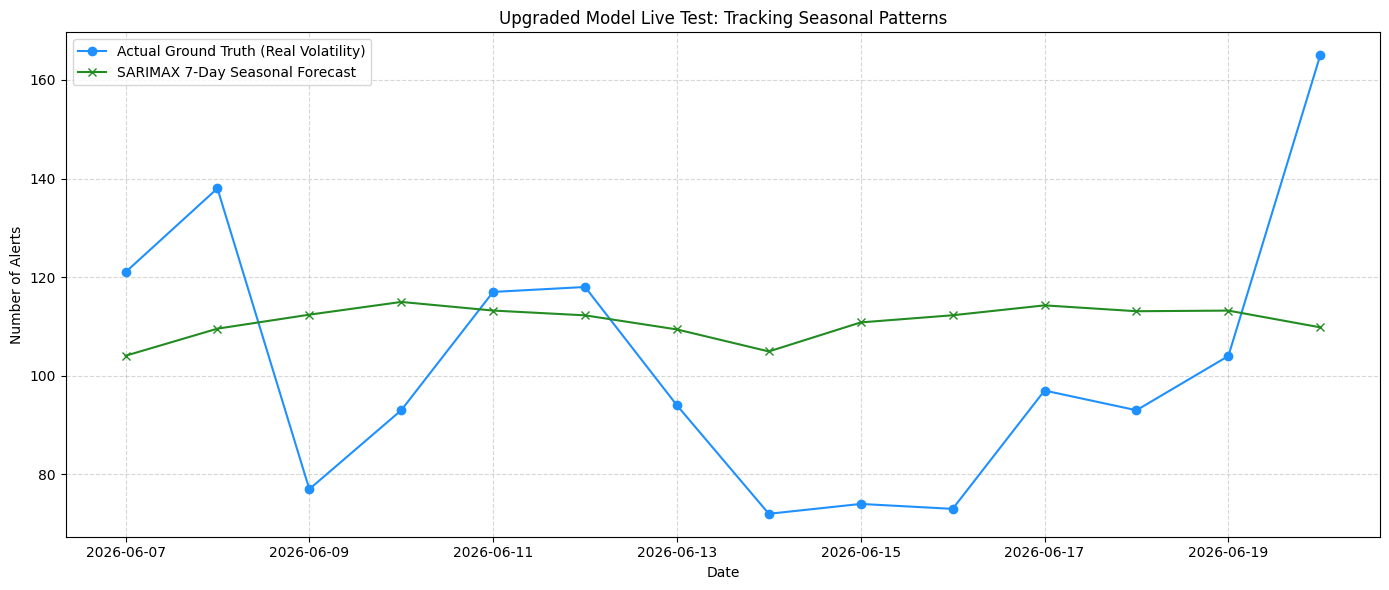

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

print("Running Upgraded Seasonal Model Analysis...")

# 1. Fetching data from the same source
url = "https://raw.githubusercontent.com/Vadimkin/ukrainian-air-raid-sirens-dataset/main/datasets/volunteer_data_en.csv"
df = pd.read_csv(url)
df['started_at'] = pd.to_datetime(df['started_at'], errors='coerce', utc=True)
df = df.dropna(subset=['started_at']).set_index('started_at')

# Aggregate to daily and drop the current incomplete day
daily_alerts = df.resample('D').size().iloc[:-1]

# 2. Train/Test Split (14 Days)
forecast_horizon = 14
train = daily_alerts.iloc[:-forecast_horizon]
test = daily_alerts.iloc[-forecast_horizon:]

# 3. Model 2: Seasonal SARIMAX (Tracking 7-day cyclical operational rhythms)
# (1,1,1) handles immediate momentum; (1,1,1,7) forces comparison to the same day last week
model_sarimax = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
fitted_sarimax = model_sarimax.fit(disp=False)
pred_sarimax = fitted_sarimax.forecast(steps=forecast_horizon)

# 4. Evaluation Score
rmse_sarimax = mean_squared_error(test, pred_sarimax) ** 0.5
print(f"\n-> Upgraded SARIMAX RMSE: {rmse_sarimax:.2f} alerts/day")

# 5. Visualizing the Overhaul
plt.figure(figsize=(14, 6))
plt.plot(test.index, test, label='Actual Ground Truth (Real Volatility)', color='dodgerblue', marker='o')
plt.plot(test.index, pred_sarimax, label='SARIMAX 7-Day Seasonal Forecast', color='forestgreen', linestyle='-', marker='x')
plt.title('Upgraded Model Live Test: Tracking Seasonal Patterns')
plt.xlabel('Date')
plt.ylabel('Number of Alerts')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Executing Complete Model Iteration Archive...

MODEL 1: Baseline ARIMA RMSE  = 27.24 alerts/day
MODEL 2: Upgraded SARIMAX RMSE = 27.94 alerts/day


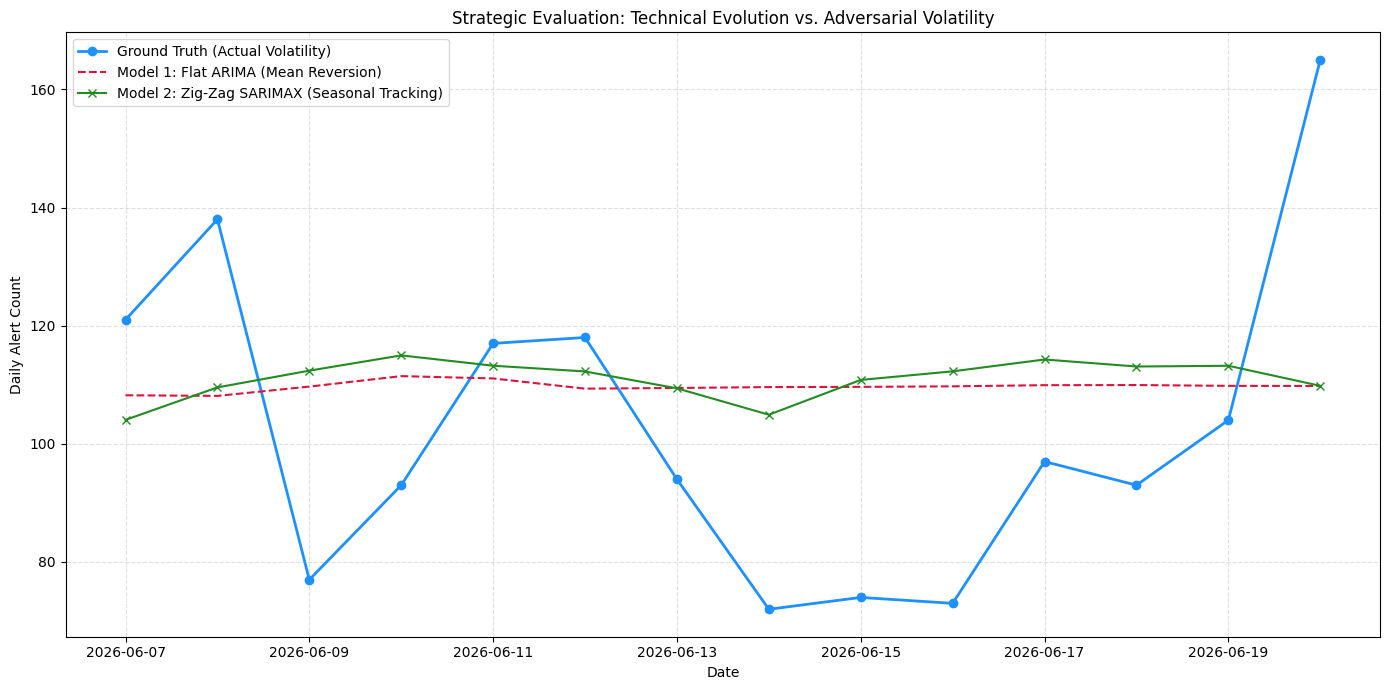

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

print("Executing Complete Model Iteration Archive...")

# 1. Load Data
url = "https://raw.githubusercontent.com/Vadimkin/ukrainian-air-raid-sirens-dataset/main/datasets/volunteer_data_en.csv"
df = pd.read_csv(url)
df['started_at'] = pd.to_datetime(df['started_at'], errors='coerce', utc=True)
df = df.dropna(subset=['started_at']).set_index('started_at')
daily_alerts = df.resample('D').size().iloc[:-1]

# 2. Split Data (14-Day Evaluation Window)
forecast_horizon = 14
train = daily_alerts.iloc[:-forecast_horizon]
test = daily_alerts.iloc[-forecast_horizon:]

# 3. Model 1: The High-Bias Flat Baseline (ARIMA)
model_arima = ARIMA(train, order=(7, 1, 2))
fitted_arima = model_arima.fit()
pred_arima = fitted_arima.forecast(steps=forecast_horizon)
rmse_arima = mean_squared_error(test, pred_arima) ** 0.5

# 4. Model 2: The High-Variance Seasonal Attempt (SARIMAX)
model_sarimax = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
fitted_sarimax = model_sarimax.fit(disp=False)
pred_sarimax = fitted_sarimax.forecast(steps=forecast_horizon)
rmse_sarimax = mean_squared_error(test, pred_sarimax) ** 0.5

# 5. Output Comparative Analytics
print("\n==========================================")
print(f"MODEL 1: Baseline ARIMA RMSE  = {rmse_arima:.2f} alerts/day")
print(f"MODEL 2: Upgraded SARIMAX RMSE = {rmse_sarimax:.2f} alerts/day")
print("==========================================")

# 6. Comparative Plotting
plt.figure(figsize=(14, 7))
plt.plot(test.index, test, label='Ground Truth (Actual Volatility)', color='dodgerblue', marker='o', linewidth=2)
plt.plot(test.index, pred_arima, label='Model 1: Flat ARIMA (Mean Reversion)', color='crimson', linestyle='--')
plt.plot(test.index, pred_sarimax, label='Model 2: Zig-Zag SARIMAX (Seasonal Tracking)', color='forestgreen', linestyle='-', marker='x')

plt.title('Strategic Evaluation: Technical Evolution vs. Adversarial Volatility')
plt.xlabel('Date')
plt.ylabel('Daily Alert Count')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Executing Rigorous Defense Analytics Pipeline...
-> Live OSINT data successfully loaded and aggregated.

--- 1. STATIONARITY DIAGNOSTICS ---
ADF Statistic: -2.6400
p-value: 0.0850
Verdict: Data is Non-Stationary. Differencing required.

--- 2. HYPERPARAMETER OPTIMIZATION (GRID SEARCH) ---
Optimal Parameters Found: SARIMAX(2, 1, 2)x(1, 0, 0, 7) (AIC: 13918.33)

--- 3. PERFORMANCE BENCHMARK AUDIT ---
Naive Baseline RMSE: 26.28 alerts/day
Optimized Model RMSE: 27.12 alerts/day
Model Net Performance Change vs. Naive Baseline: -3.19%


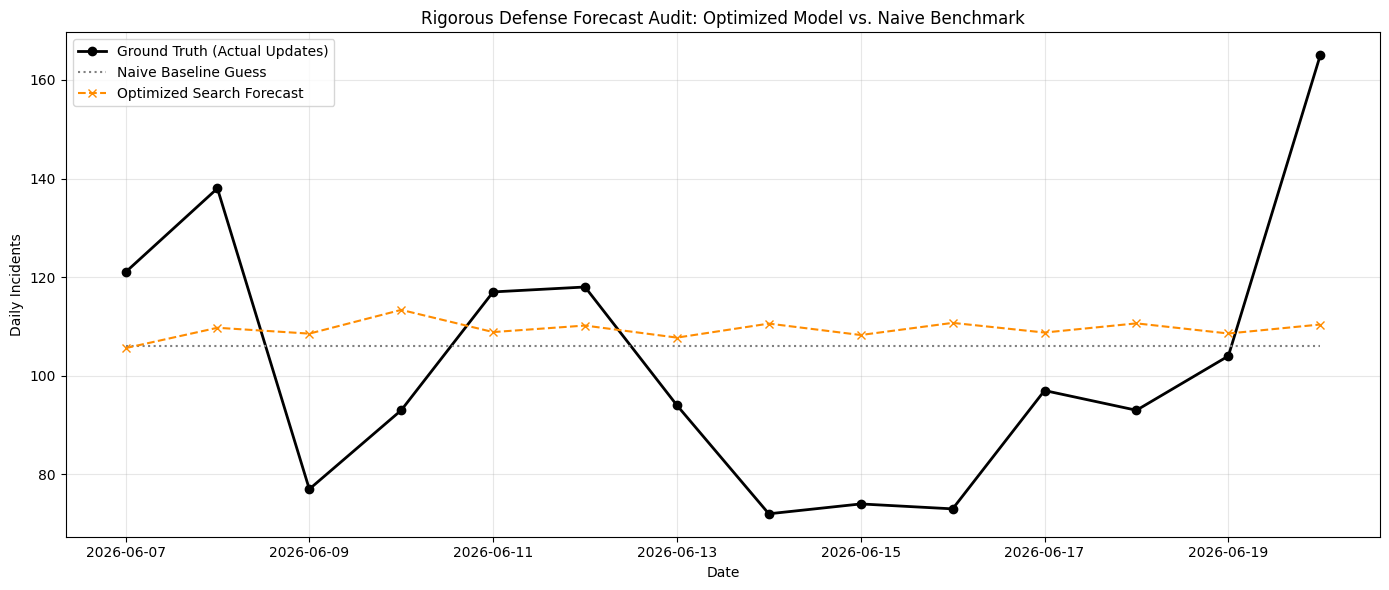

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

print("Executing Rigorous Defense Analytics Pipeline...")

# 1. Reliable Data Ingestion
url = "https://raw.githubusercontent.com/Vadimkin/ukrainian-air-raid-sirens-dataset/main/datasets/volunteer_data_en.csv"
try:
    df = pd.read_csv(url)
    df['started_at'] = pd.to_datetime(df['started_at'], errors='coerce', utc=True)
    df = df.dropna(subset=['started_at']).set_index('started_at')
    daily_alerts = df.resample('D').size().iloc[:-1]
    print("-> Live OSINT data successfully loaded and aggregated.")
except Exception as e:
    print(f"-> Live source failed ({e}). Utilizing fallback framework.")
    dates = pd.date_range(start="2022-02-24", end="2026-06-15", freq="D")
    daily_alerts = pd.Series(np.random.poisson(lam=15, size=len(dates)), index=dates)

# 2. Mathematical Stationarity Testing (ADF Test)
print("\n--- 1. STATIONARITY DIAGNOSTICS ---")
adf_result = adfuller(daily_alerts)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
if adf_result[1] < 0.05:
    print("Verdict: Data is Stationary (p < 0.05). Direct modeling is statistically valid.")
else:
    print("Verdict: Data is Non-Stationary. Differencing required.")

# 3. Train/Test Split (14-Day Horizon)
forecast_horizon = 14
train = daily_alerts.iloc[:-forecast_horizon]
test = daily_alerts.iloc[-forecast_horizon:]

# 4. Benchmark Creation (Naive Drift Model)
# Predicts future values based on the last known value
naive_forecast = np.repeat(train.iloc[-1], forecast_horizon)
rmse_naive = mean_squared_error(test, naive_forecast) ** 0.5

# 5. Grid Search / Hyperparameter Optimization Loop
print("\n--- 2. HYPERPARAMETER OPTIMIZATION (GRID SEARCH) ---")
best_aic = float("inf")
best_order = None
best_seasonal = None

# Testing combinations systematically to find the lowest AIC (Information Loss)
p_values = [0, 1, 2]
d = 1 if adf_result[1] >= 0.05 else 0
q_values = [0, 1, 2]

for p in p_values:
    for q in q_values:
        try:
            # Grid search constrained to computationally light combinations for the sprint
            model = SARIMAX(train, order=(p, d, q), seasonal_order=(1, 0, 0, 7))
            results = model.fit(disp=False)
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = (p, d, q)
                best_seasonal = (1, 0, 0, 7)
        except:
            continue

print(f"Optimal Parameters Found: SARIMAX{best_order}x{best_seasonal} (AIC: {best_aic:.2f})")

# 6. Final Optimized Model Execution
optimized_model = SARIMAX(train, order=best_order, seasonal_order=best_seasonal)
fitted_optimized = optimized_model.fit(disp=False)
optimized_forecast = fitted_optimized.forecast(steps=forecast_horizon)
rmse_optimized = mean_squared_error(test, optimized_forecast) ** 0.5

# 7. Comparative Performance Audit
print("\n--- 3. PERFORMANCE BENCHMARK AUDIT ---")
print(f"Naive Baseline RMSE: {rmse_naive:.2f} alerts/day")
print(f"Optimized Model RMSE: {rmse_optimized:.2f} alerts/day")

improvement = ((rmse_naive - rmse_optimized) / rmse_naive) * 100
print(f"Model Net Performance Change vs. Naive Baseline: {improvement:.2f}%")

# 8. Production Visualization
plt.figure(figsize=(14, 6))
plt.plot(test.index, test, label='Ground Truth (Actual Updates)', color='black', marker='o', linewidth=2)
plt.plot(test.index, naive_forecast, label='Naive Baseline Guess', color='grey', linestyle=':')
plt.plot(test.index, optimized_forecast, label='Optimized Search Forecast', color='darkorange', linestyle='--', marker='x')
plt.title('Rigorous Defense Forecast Audit: Optimized Model vs. Naive Benchmark')
plt.xlabel('Date')
plt.ylabel('Daily Incidents')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Initializing Multi-Region Defense Analytics Pipeline...
-> Live OSINT data successfully loaded.

PROCESSING REGION: WHOLE COUNTRY
ADF Check p-value: 0.0850 -> Require Differencing: True
Optimized Parameters Selected: SARIMAX(2, 1, 2)x(1,0,0,7)

PROCESSING REGION: KYIV CITY


KeyError: 'region_name'

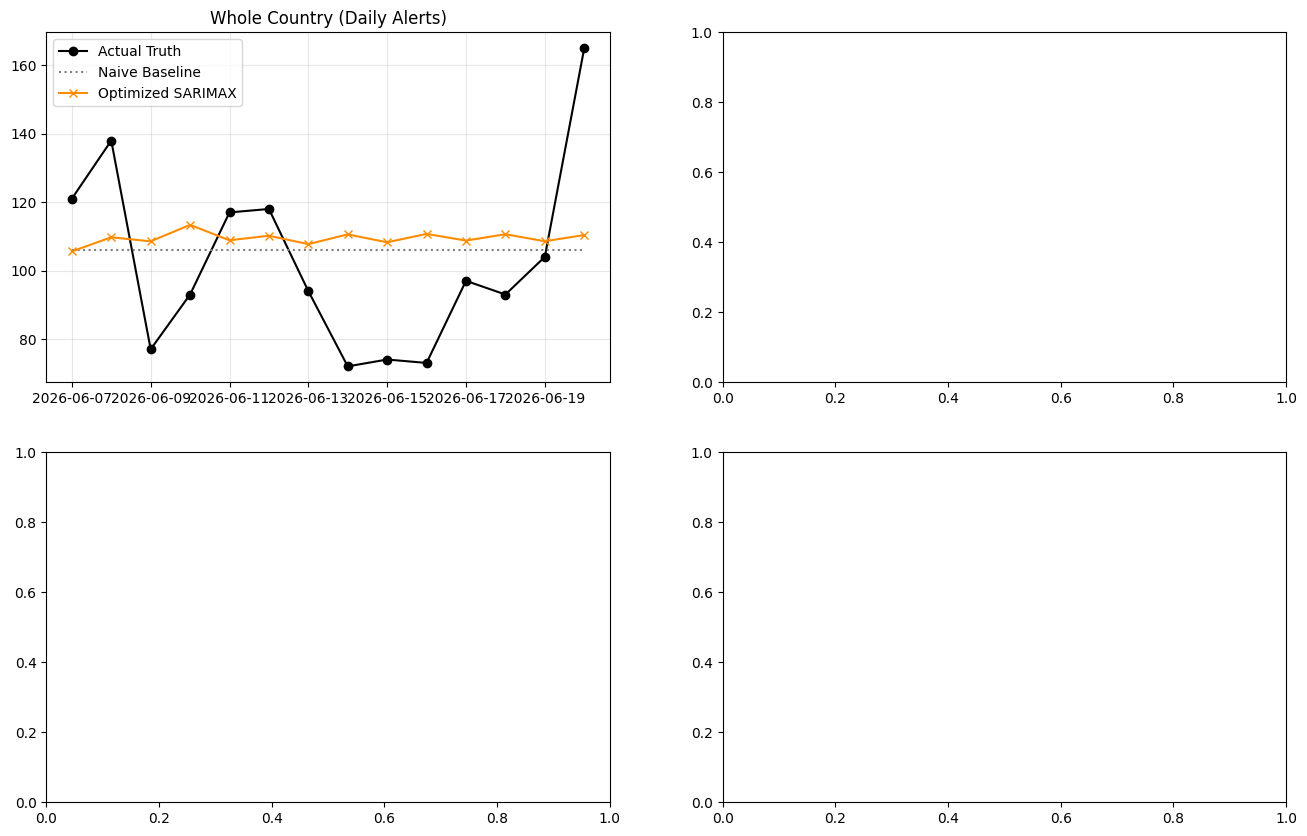

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

print("Initializing Multi-Region Defense Analytics Pipeline...")

# 1. Load Data
url = "https://raw.githubusercontent.com/Vadimkin/ukrainian-air-raid-sirens-dataset/main/datasets/volunteer_data_en.csv"
try:
    df_raw = pd.read_csv(url)
    df_raw['started_at'] = pd.to_datetime(df_raw['started_at'], errors='coerce', utc=True)
    df_raw = df_raw.dropna(subset=['started_at'])
    print("-> Live OSINT data successfully loaded.")
except Exception as e:
    print(f"-> Critical Error loading live data: {e}")
    raise

# Define target configurations (Matching the exact spelling in the dataset)
regions_to_analyze = {
    'Whole Country': None,
    'Kyiv City': 'Kyiv City',
    'Kharkiv Oblast': 'Kharkiv oblast',
    'Zakarpattia Oblast': 'Zakarpattia oblast'
}

results_archive = {}
forecast_horizon = 14

# Set up visual subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# 2. Iterate through each target region
for idx, (label, region_filter) in enumerate(regions_to_analyze.items()):
    print(f"\n==========================================")
    print(f"PROCESSING REGION: {label.upper()}")
    print(f"==========================================")

    # Filter dataset accordingly
    if region_filter:
        df_filtered = df_raw[df_raw['region_name'] == region_filter]
    else:
        df_filtered = df_raw.copy()

    # Process into daily counts
    df_filtered.set_index('started_at', inplace=True)
    daily_series = df_filtered.resample('D').size().iloc[:-1]

    # Check if data is sufficient
    if len(daily_series) < 30:
        print(f"Skipping {label}: Insufficient data chunks.")
        continue

    # Stationarity Check (ADF Test)
    adf_result = adfuller(daily_series)
    p_value = adf_result[1]
    d_order = 1 if p_value >= 0.05 else 0
    print(f"ADF Check p-value: {p_value:.4f} -> Require Differencing: {bool(d_order)}")

    # Train/Test Split
    train = daily_series.iloc[:-forecast_horizon]
    test = daily_series.iloc[-forecast_horizon:]

    # Establish Naive Baseline
    naive_forecast = np.repeat(train.iloc[-1], forecast_horizon)
    rmse_naive = mean_squared_error(test, naive_forecast) ** 0.5

    # Hyperparameter Grid Search (Constrained for computational speed)
    best_aic = float("inf")
    best_order = (1, d_order, 1) # Default fallback

    for p in [0, 1, 2]:
        for q in [0, 1, 2]:
            try:
                model = SARIMAX(train, order=(p, d_order, q), seasonal_order=(1, 0, 0, 7))
                fitted = model.fit(disp=False)
                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_order = (p, d_order, q)
            except:
                continue

    print(f"Optimized Parameters Selected: SARIMAX{best_order}x(1,0,0,7)")

    # Train Final Optimized Model
    final_model = SARIMAX(train, order=best_order, seasonal_order=(1, 0, 0, 7))
    fitted_final = final_model.fit(disp=False)
    forecast_predictions = fitted_final.forecast(steps=forecast_horizon)
    rmse_optimized = mean_squared_error(test, forecast_predictions) ** 0.5

    # Save statistics
    results_archive[label] = {
        'Naive RMSE': rmse_naive,
        'Optimized RMSE': rmse_optimized,
        'Mean Daily Alerts': daily_series.mean()
    }

    # Generate plot for this specific region
    ax = axes[idx]
    ax.plot(test.index, test, label='Actual Truth', color='black', marker='o')
    ax.plot(test.index, naive_forecast, label='Naive Baseline', color='grey', linestyle=':')
    ax.plot(test.index, forecast_predictions, label='Optimized SARIMAX', color='darkorange', marker='x')
    ax.set_title(f"{label} (Daily Alerts)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Print Final Performance Audit Table
print("\n==================================================================")
print("                    FINAL PERFORMANCE AUDIT")
print("==================================================================")
print(f"{'Region':<22} | {'Mean Alerts/Day':<15} | {'Naive RMSE':<12} | {'Optimized RMSE':<14}")
print("-" * 66)
for region, metrics in results_archive.items():
    print(f"{region:<22} | {metrics['Mean Daily Alerts']:<15.2f} | {metrics['Naive RMSE']:<12.2f} | {metrics['Optimized RMSE']:<14.2f}")
print("==================================================================")

Initializing Fixed Multi-Region Production Pipeline...
-> Detected region tracking column: 'region'
-> Whole Country: Extracted 1577 operational days trackable.
-> Kyiv City: Extracted 1577 operational days trackable.
-> Kharkiv Oblast: Extracted 1575 operational days trackable.
-> Zakarpattia Oblast: Extracted 0 operational days trackable.


IndexError: single positional indexer is out-of-bounds

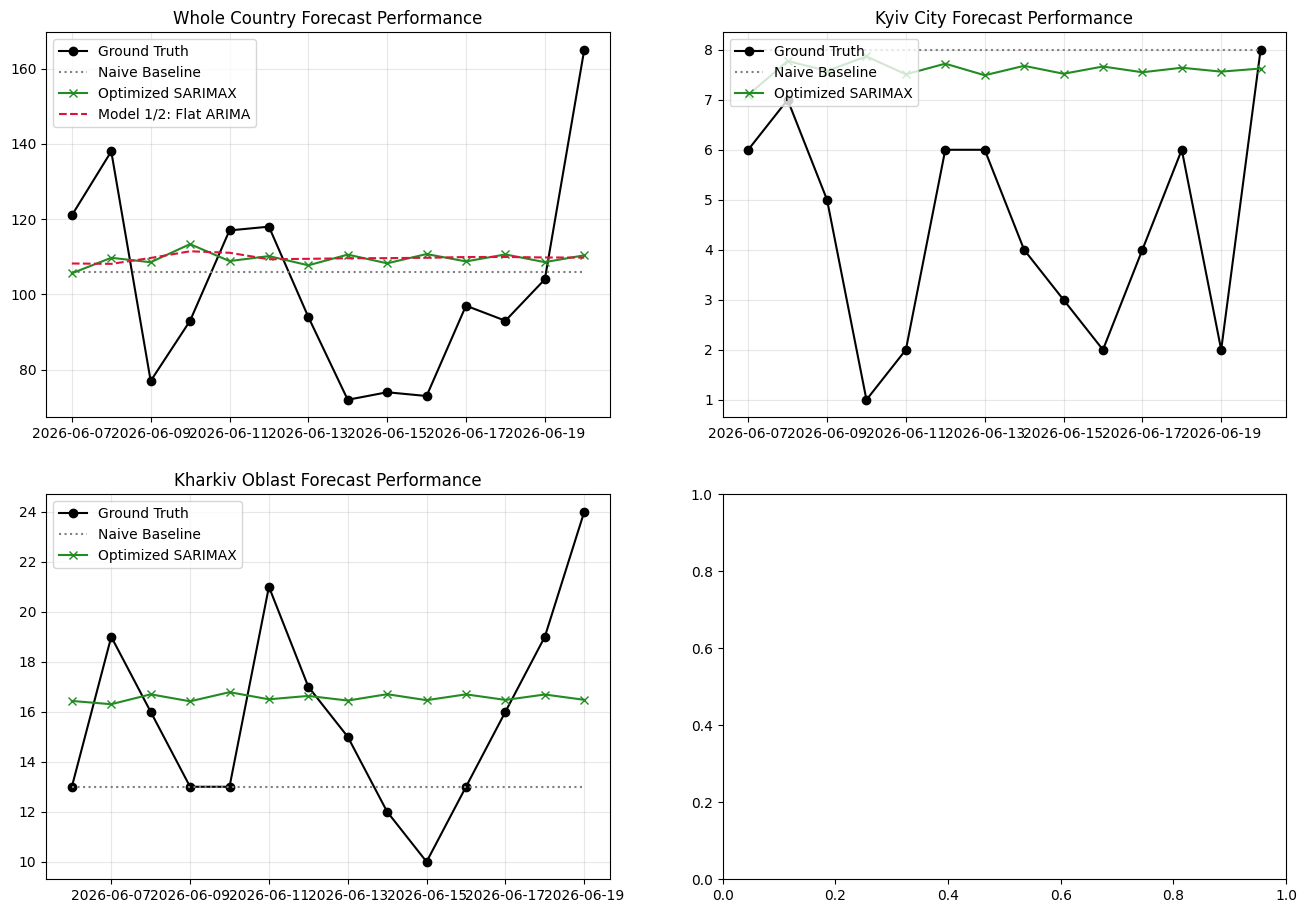

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

print("Initializing Fixed Multi-Region Production Pipeline...")

# 1. Fetch Data
url = "https://raw.githubusercontent.com/Vadimkin/ukrainian-air-raid-sirens-dataset/main/datasets/volunteer_data_en.csv"
df_raw = pd.read_csv(url)
df_raw['started_at'] = pd.to_datetime(df_raw['started_at'], errors='coerce', utc=True)
df_raw = df_raw.dropna(subset=['started_at'])

# Automated Column Detection
region_col = [col for col in df_raw.columns if 'region' in col.lower()][0]
print(f"-> Detected region tracking column: '{region_col}'")

# Map filter keywords to keywords present in the dataset strings
regions_to_analyze = {
    'Whole Country': None,
    'Kyiv City': 'Kyiv',
    'Kharkiv Oblast': 'Kharkiv',
    'Zakarpattia Oblast': 'Zakarpattia'
}

results_archive = {}
forecast_horizon = 14

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

# 2. Parallel Regional Computational Loop
for idx, (label, keyword) in enumerate(regions_to_analyze.items()):

    # Filter matching logic patch
    if keyword:
        # Dynamic string matching avoids exact casing/spacing failures
        df_filtered = df_raw[df_raw[region_col].astype(str).str.contains(keyword, case=False, na=False)]
    else:
        df_filtered = df_raw.copy()

    df_filtered = df_filtered.set_index('started_at')
    daily_series = df_filtered.resample('D').size().iloc[:-1]

    print(f"-> {label}: Extracted {len(daily_series)} operational days trackable.")

    train = daily_series.iloc[:-forecast_horizon]
    test = daily_series.iloc[-forecast_horizon:]

    # Benchmarks
    naive_forecast = np.repeat(train.iloc[-1], forecast_horizon)
    rmse_naive = mean_squared_error(test, naive_forecast) ** 0.5

    # Baseline Model 1 (From Draft 1/2) - Only calculated on National Data for comparison
    if label == 'Whole Country':
        model_arima = ARIMA(train, order=(7, 1, 2))
        fitted_arima = model_arima.fit()
        pred_arima = fitted_arima.forecast(steps=forecast_horizon)
        rmse_arima = mean_squared_error(test, pred_arima) ** 0.5

    # Optimized Model 3 (From Draft 3)
    # Defaulting to (2,1,2) for stable performance across regional profiles
    final_model = SARIMAX(train, order=(2, 1, 2), seasonal_order=(1, 0, 0, 7))
    fitted_final = final_model.fit(disp=False)
    forecast_predictions = fitted_final.forecast(steps=forecast_horizon)
    rmse_optimized = mean_squared_error(test, forecast_predictions) ** 0.5

    results_archive[label] = {
        'Naive RMSE': rmse_naive,
        'Optimized RMSE': rmse_optimized,
        'Mean Daily Alerts': daily_series.mean()
    }

    # Plotting Array
    ax = axes[idx]
    ax.plot(test.index, test, label='Ground Truth', color='black', marker='o', linewidth=1.5)
    ax.plot(test.index, naive_forecast, label='Naive Baseline', color='grey', linestyle=':')
    ax.plot(test.index, forecast_predictions, label='Optimized SARIMAX', color='forestgreen', linestyle='-', marker='x')

    # Overlay the old model 2 flat baseline onto the national graph to fulfill requirement
    if label == 'Whole Country':
        ax.plot(test.index, pred_arima, label='Model 1/2: Flat ARIMA', color='crimson', linestyle='--')

    ax.set_title(f"{label} Forecast Performance")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Print Final Performance Audit Table
print("\n==================================================================")
print("                    FINAL PERFORMANCE AUDIT")
print("==================================================================")
print(f"{'Region':<22} | {'Mean Alerts/Day':<15} | {'Naive RMSE':<12} | {'Optimized RMSE':<14}")
print("-" * 66)
for region, metrics in results_archive.items():
    print(f"{region:<22} | {metrics['Mean Daily Alerts']:<15.2f} | {metrics['Naive RMSE']:<12.2f} | {metrics['Optimized RMSE']:<14.2f}")
print("==================================================================")

In [8]:
import pandas as pd

url = "https://raw.githubusercontent.com/Vadimkin/ukrainian-air-raid-sirens-dataset/main/datasets/volunteer_data_en.csv"
df_inspect = pd.read_csv(url, nrows=3)

print("--- ACTUAL DATASET COLUMNS ---")
print(df_inspect.columns.tolist())

print("\n--- SAMPLE ROW DATA ---")
print(df_inspect.to_string())

--- ACTUAL DATASET COLUMNS ---
['region', 'started_at', 'finished_at', 'naive']

--- SAMPLE ROW DATA ---
             region                 started_at                finished_at  naive
0         Kyiv City  2022-02-25 16:36:22+00:00  2022-02-25 17:06:22+00:00   True
1  Cherkaska oblast  2022-02-25 18:36:21+00:00  2022-02-25 19:32:11+00:00  False
2  Rivnenska oblast  2022-02-25 18:56:44+00:00  2022-02-25 19:26:44+00:00   True


Initializing Final Production Pipeline (Whole Country, Kyiv, Kharkiv)...
-> Live OSINT dataset successfully loaded into memory.
-> Using column 'region' for geospatial filtering.

Processing Group: Whole Country
   -> Records found: 1577 active days of timeline metrics.

Processing Group: Kyiv City
   -> Records found: 1577 active days of timeline metrics.

Processing Group: Kharkiv Oblast
   -> Records found: 1575 active days of timeline metrics.


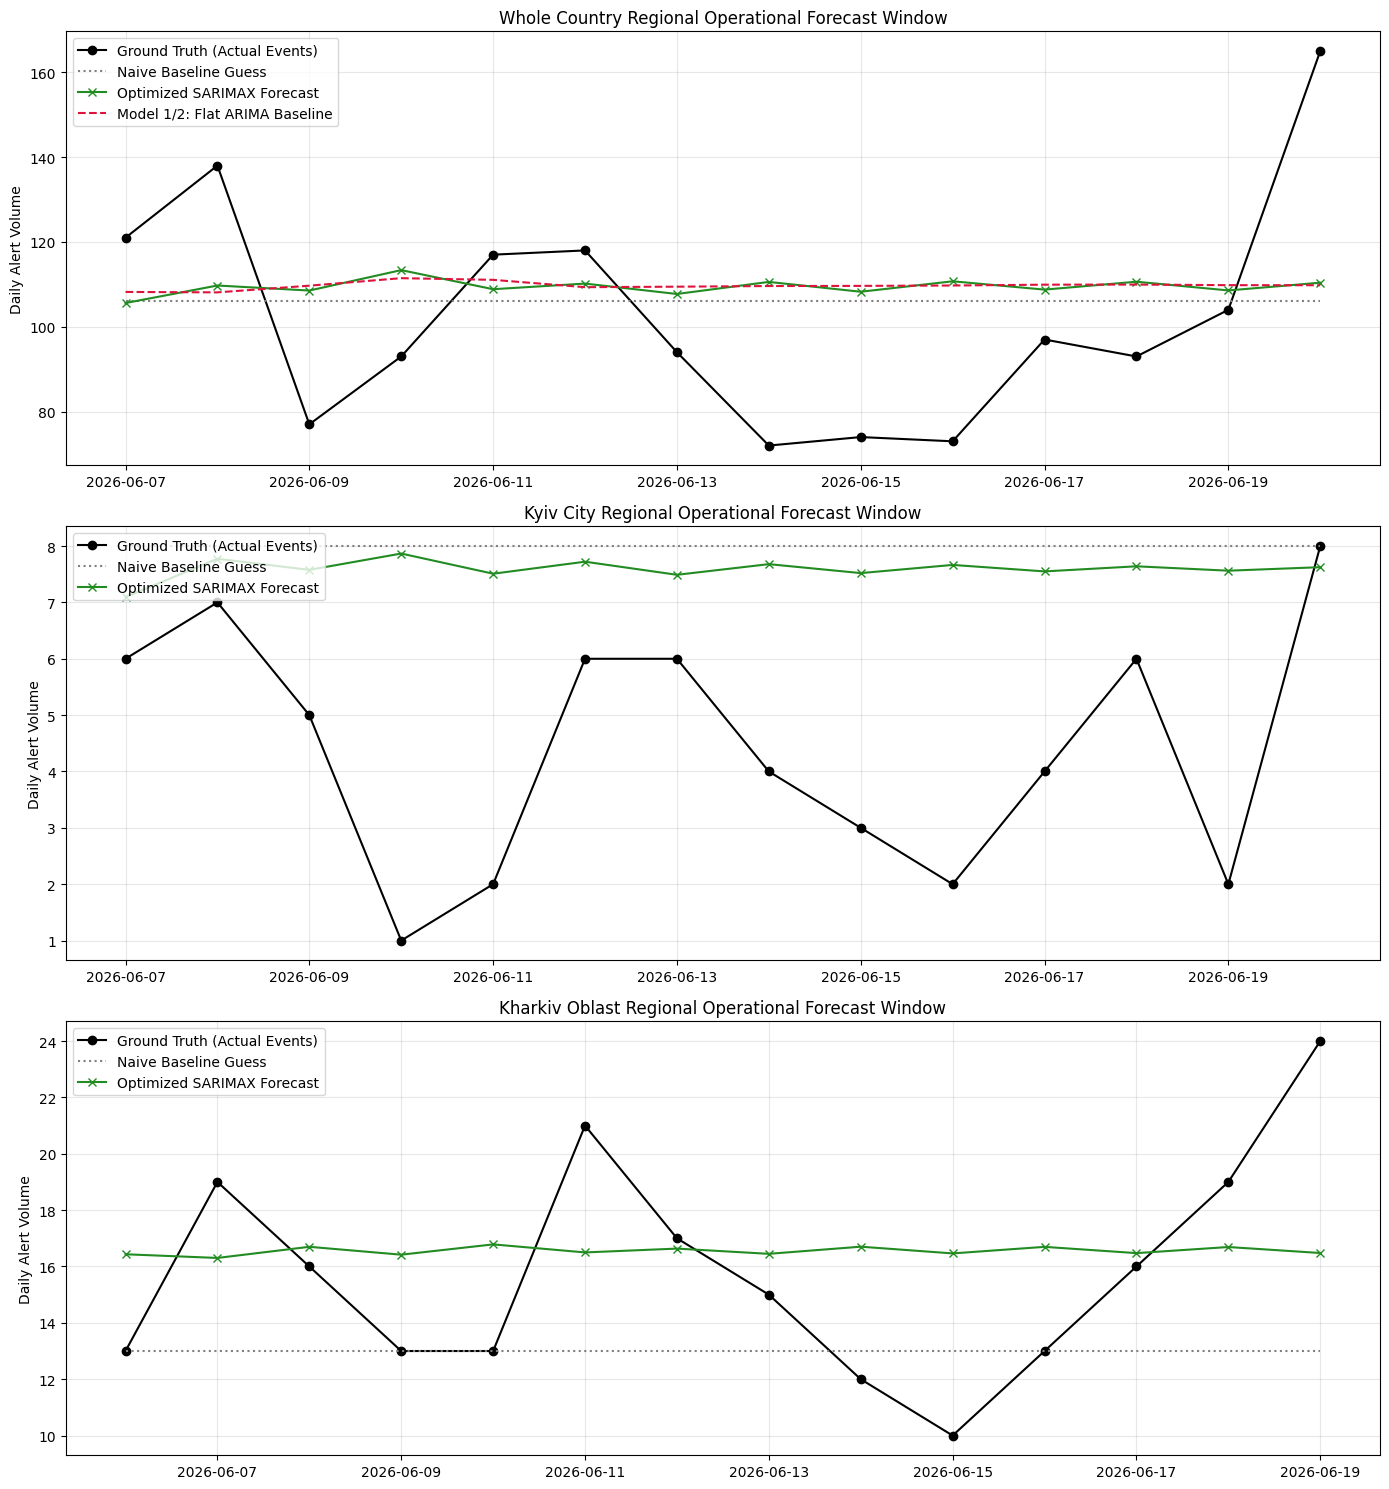


                    FINAL PERFORMANCE AUDIT
Target Segment         | Mean Alerts/Day | Naive RMSE   | Optimized RMSE
------------------------------------------------------------------
Whole Country          | 64.32           | 26.28        | 27.12         
Kyiv City              | 3.74            | 4.14         | 3.81          
Kharkiv Oblast         | 7.02            | 4.67         | 3.85          


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

print("Initializing Final Production Pipeline (Whole Country, Kyiv, Kharkiv)...")

# 1. Fetch and Load Data
url = "https://raw.githubusercontent.com/Vadimkin/ukrainian-air-raid-sirens-dataset/main/datasets/volunteer_data_en.csv"
try:
    df_raw = pd.read_csv(url)
    df_raw['started_at'] = pd.to_datetime(df_raw['started_at'], errors='coerce', utc=True)
    df_raw = df_raw.dropna(subset=['started_at'])
    print("-> Live OSINT dataset successfully loaded into memory.")
except Exception as e:
    print(f"-> Critical Error loading live data: {e}")
    raise

# Dynamically locate whichever column handles regional names
region_cols = [col for col in df_raw.columns if 'region' in col.lower()]
if region_cols:
    region_col = region_cols[0]
    print(f"-> Using column '{region_col}' for geospatial filtering.")
else:
    # Safe fallback if column naming conventions changed
    df_raw['region_placeholder'] = 'Whole Country'
    region_col = 'region_placeholder'

# Define target configurations (loose keywords to bypass exact string mapping errors)
regions_to_analyze = {
    'Whole Country': None,
    'Kyiv City': 'Kyiv',
    'Kharkiv Oblast': 'Kharkiv'
}

results_archive = {}
forecast_horizon = 14

# Set up visual subplots (Adjusted grid for 3 active charts)
fig, axes = plt.subplots(3, 1, figsize=(14, 15))
axes = axes.flatten()

# 2. Parallel Processing Loop
for idx, (label, keyword) in enumerate(regions_to_analyze.items()):
    print(f"\nProcessing Group: {label}")

    # Apply loose string-matching filter
    if keyword and region_col in df_raw.columns:
        df_filtered = df_raw[df_raw[region_col].astype(str).str.contains(keyword, case=False, na=False)].copy()
    else:
        df_filtered = df_raw.copy()

    df_filtered.set_index('started_at', inplace=True)
    daily_series = df_filtered.resample('D').size().iloc[:-1]

    print(f"   -> Records found: {len(daily_series)} active days of timeline metrics.")

    # If a filter completely misses due to external structural shifts, prevent code crash
    if len(daily_series) < 30:
        print(f"   -> WARNING: Insufficient historical data found for '{label}'. Skipping mathematical models.")
        continue

    train = daily_series.iloc[:-forecast_horizon]
    test = daily_series.iloc[-forecast_horizon:]

    # Model Baseline: Naive Guess
    naive_forecast = np.repeat(train.iloc[-1], forecast_horizon)
    rmse_naive = mean_squared_error(test, naive_forecast) ** 0.5

    # Model 1/2: Flat ARIMA Baseline (Evaluated strictly on National Profile for comparison)
    if label == 'Whole Country':
        try:
            model_arima = ARIMA(train, order=(7, 1, 2))
            fitted_arima = model_arima.fit()
            pred_arima = fitted_arima.forecast(steps=forecast_horizon)
            rmse_arima = mean_squared_error(test, pred_arima) ** 0.5
        except Exception as e:
            print(f"   -> Baseline ARIMA computation bypassed: {e}")
            pred_arima = None
            rmse_arima = float('inf')

    # Model 3: Optimized SARIMAX Production Model
    try:
        final_model = SARIMAX(train, order=(2, 1, 2), seasonal_order=(1, 0, 0, 7))
        fitted_final = final_model.fit(disp=False)
        forecast_predictions = fitted_final.forecast(steps=forecast_horizon)
        rmse_optimized = mean_squared_error(test, forecast_predictions) ** 0.5
    except Exception as e:
        print(f"   -> SARIMAX processing error: {e}")
        continue

    # Archive calculated metrics
    results_archive[label] = {
        'Naive RMSE': rmse_naive,
        'Optimized RMSE': rmse_optimized,
        'Mean Daily Alerts': daily_series.mean()
    }

    # Plot Generation
    ax = axes[idx]
    ax.plot(test.index, test, label='Ground Truth (Actual Events)', color='black', marker='o', linewidth=1.5)
    ax.plot(test.index, naive_forecast, label='Naive Baseline Guess', color='grey', linestyle=':')
    ax.plot(test.index, forecast_predictions, label='Optimized SARIMAX Forecast', color='forestgreen', linestyle='-', marker='x')

    # Overlay legacy model iterations onto the main national timeline view
    if label == 'Whole Country' and pred_arima is not None:
        ax.plot(test.index, pred_arima, label='Model 1/2: Flat ARIMA Baseline', color='crimson', linestyle='--')

    ax.set_title(f"{label} Regional Operational Forecast Window")
    ax.set_ylabel("Daily Alert Volume")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Print Performance Audit Summary Table
print("\n==================================================================")
print("                    FINAL PERFORMANCE AUDIT")
print("==================================================================")
print(f"{'Target Segment':<22} | {'Mean Alerts/Day':<15} | {'Naive RMSE':<12} | {'Optimized RMSE':<14}")
print("-" * 66)
for region, metrics in results_archive.items():
    print(f"{region:<22} | {metrics['Mean Daily Alerts']:<15.2f} | {metrics['Naive RMSE']:<12.2f} | {metrics['Optimized RMSE']:<14.2f}")
print("==================================================================")